# 00 — Sanity checks: BTCUSDT daily 5-min realized variance

Source file: `data/derived/btcusdt_rv5_daily.csv`. Flagged days (`flag == True`) are set to NaN below.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
df = pd.read_csv(ROOT / "data" / "derived" / "btcusdt_rv5_daily.csv", parse_dates=["date"])
df = df.set_index("date")
rv = df["rv5"].where(~df["flag"])
log_rv = np.log(rv.where(rv > 0))

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e3e3e3", "grid.linewidth": 0.6,
    "axes.edgecolor": "#888888", "font.size": 10,
})
COLOR = "#2a6fb0"
print(f"days: {len(df)} | flagged: {int(df['flag'].sum())} | used: {int(log_rv.notna().sum())}")
print(f"range: {df.index.min().date()} -> {df.index.max().date()}")

days: 3165 | flagged: 26 | used: 3139
range: 2018-01-01 -> 2026-08-31


## Daily RV (log scale)

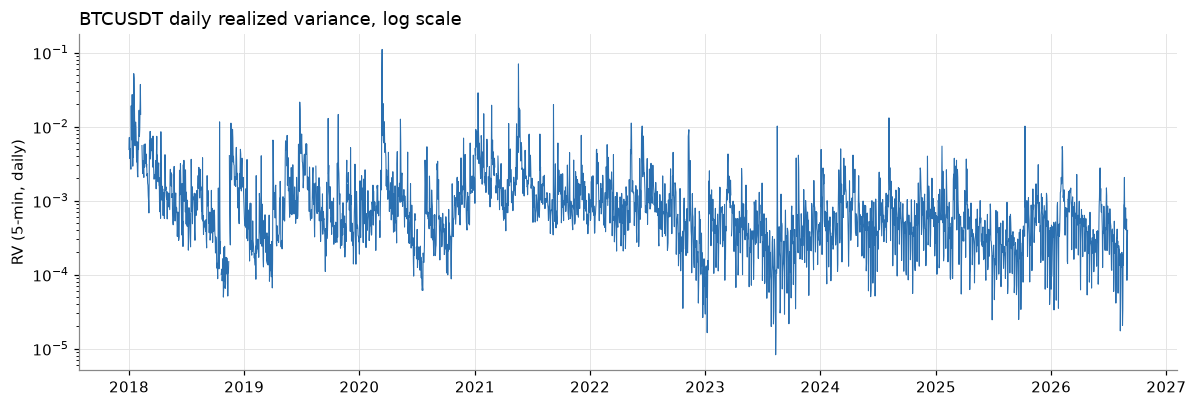

In [2]:
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(rv.index, rv.values, color=COLOR, linewidth=0.7)
ax.set_yscale("log")
ax.set_ylabel("RV (5-min, daily)")
ax.set_title("BTCUSDT daily realized variance, log scale", loc="left")
fig.tight_layout()
plt.show()

## Histogram of log(RV)

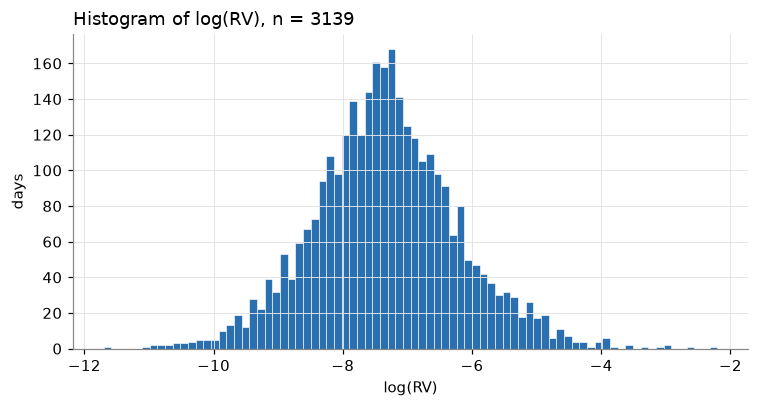

In [3]:
x = log_rv.dropna()
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(x, bins=80, color=COLOR, edgecolor="white", linewidth=0.4)
ax.set_xlabel("log(RV)")
ax.set_ylabel("days")
ax.set_title(f"Histogram of log(RV), n = {len(x)}", loc="left")
fig.tight_layout()
plt.show()

## ACF of log(RV), lags 1–100

Computed on the calendar-day grid with pairwise-complete observations (flagged days are NaN, not removed).

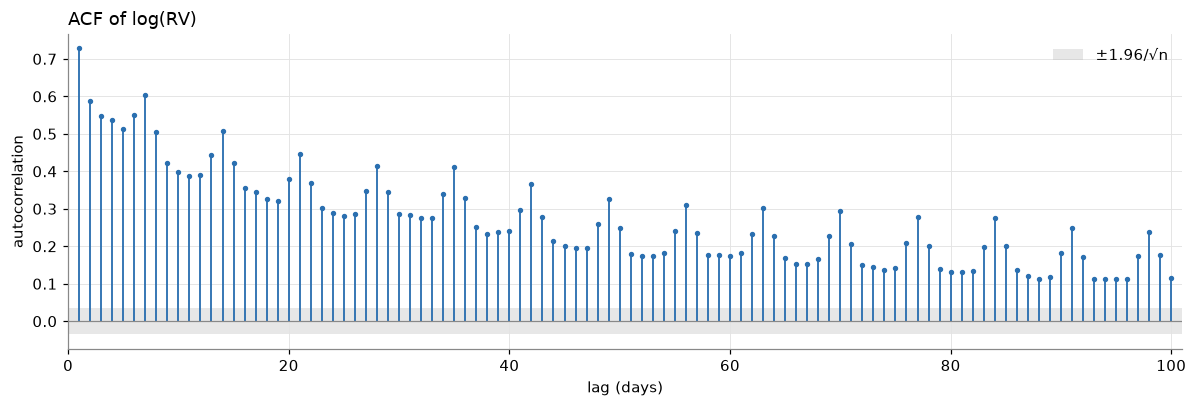

,1,5,10,22,50,100
acf,0.727884,0.513097,0.399251,0.369604,0.248014,0.115983


In [4]:
def acf_pairwise(s: pd.Series, nlags: int) -> np.ndarray:
    v = s.to_numpy(dtype=float)
    ok = ~np.isnan(v)
    z = np.where(ok, v - np.nanmean(v), 0.0)
    denom = np.sum(z[ok] ** 2) / ok.sum()
    out = np.empty(nlags + 1)
    for k in range(nlags + 1):
        both = ok[: len(v) - k] & ok[k:]
        out[k] = np.sum(z[: len(v) - k][both] * z[k:][both]) / both.sum() / denom
    return out

NLAGS = 100
acf = acf_pairwise(log_rv, NLAGS)
n = int(log_rv.notna().sum())
band = 1.96 / np.sqrt(n)

fig, ax = plt.subplots(figsize=(11, 3.8))
lags = np.arange(1, NLAGS + 1)
ax.vlines(lags, 0, acf[1:], color=COLOR, linewidth=1.2)
ax.plot(lags, acf[1:], "o", color=COLOR, markersize=2.5)
ax.axhline(0, color="#888888", linewidth=0.8)
ax.axhspan(-band, band, color="#bbbbbb", alpha=0.35, linewidth=0, label="±1.96/√n")
ax.set_xlim(0, NLAGS + 1)
ax.set_xlabel("lag (days)")
ax.set_ylabel("autocorrelation")
ax.set_title("ACF of log(RV)", loc="left")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()

pd.Series(acf[[1, 5, 10, 22, 50, 100]], index=[1, 5, 10, 22, 50, 100], name="acf").to_frame().T